# 02 — Descriptive Statistics

This notebook reads only the canonical artefacts produced by `01_ingest.ipynb`:

- `data/raw/activities_raw.parquet`
- `data/streams/streams.parquet`

No raw export is touched here. The goal is to **frame the modelling task in 03**: confirm that HR carries through cleanly, that grade-adjustment behaves as expected, that taper is visible before each race, and that Strava's `Relative Effort` and `Perceived Exertion` are *consistent* with HR/GAP-derived load (justifying their use as diagnostic guides rather than as the regression target).

Race dates (used as visual anchors throughout):

| Date | Notes |
| --- | --- |
| 2023-12-03 | Köln Nikolauslauf |
| 2024-04-14 | Bonn Halbmarathon |
| 2024-07-03 | Aachen Lousberglauf |
| 2024-10-19 | München DIY-Triathlon |
| 2025-06-29 | Schwarzwahld Drachentriathlon |
| 2026-04-12 | Milano Marathon |

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
assert PROJECT_ROOT.name == "Project"
DATA_DIR = PROJECT_ROOT / "data"

raw     = pd.read_parquet(DATA_DIR / "raw" / "activities_raw.parquet")
streams = pd.read_parquet(DATA_DIR / "streams" / "streams.parquet")

RACE_DATES = pd.to_datetime([
    "2023-12-03", "2024-04-14", "2024-07-03",
    "2024-10-19", "2025-06-29", "2026-04-12",
], utc=True)

print(f"raw: {len(raw):,} activities  | streams: {len(streams):,} rows")
print(raw.groupby("discipline").size().astype(int).rename("count"))


raw: 673 activities  | streams: 2,135,613 rows
discipline
cycling     49
hiking      13
running    611
Name: count, dtype: int64


## 2.1 Activity Volume, Duration & Elevation per Discipline

Run/Ride/Hike differ in distance scale, pace and elevation profile. We confirm that visually before pooling them anywhere. **Modelling is run-only**; cycling/hiking enter only via the load context (see 2.4).

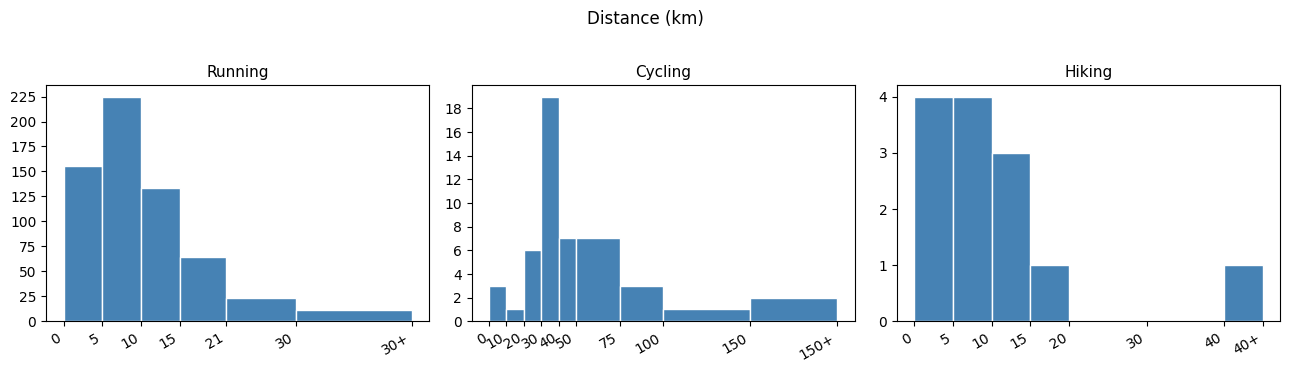

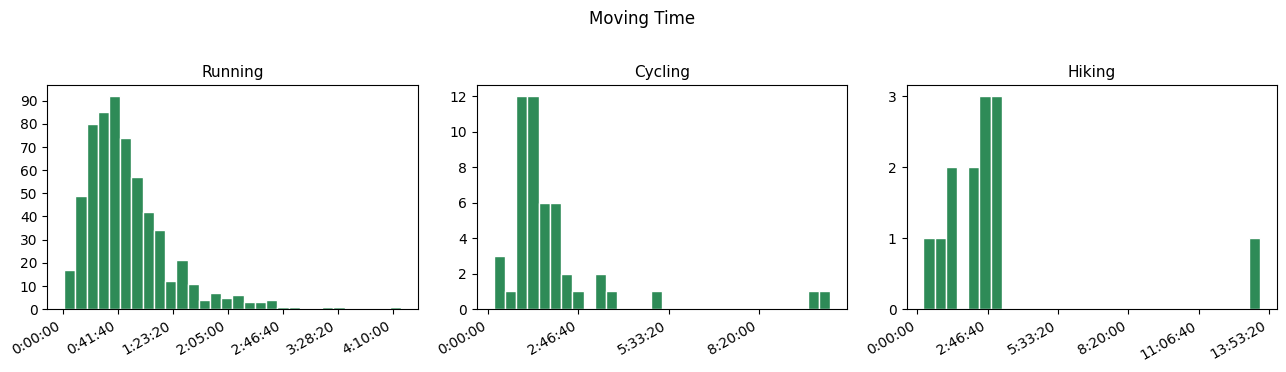

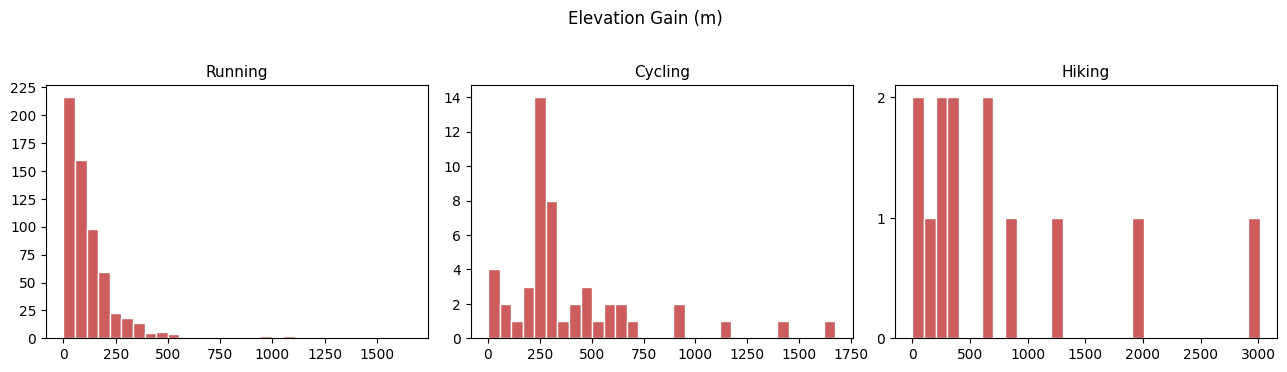

In [34]:
import matplotlib.ticker as mticker

# Distance bins per discipline (km). Uniform 5 km bins; the last edge is a finite cap
# and the right-most tick is relabelled as "40+" so the rightmost bucket reads open-ended.
DIST_BINS = {
    "running": [0, 5, 10, 15, 21, 30, 45],
    "cycling": [0, 10, 20, 30, 40, 50, 75, 100, 150, 200],
    "hiking":  [0, 5, 10, 15, 20, 30, 40, 45],
}

def hms_formatter(seconds, _):
    """Render a seconds value as h:mm:ss for matplotlib tick labels."""
    s = int(seconds)
    return f"{s//3600}:{(s%3600)//60:02d}:{s%60:02d}"

DISCIPLINES = ["running", "cycling", "hiking"]

# Distance: discipline-specific bins; right-most bucket is open-ended.
if "Distance" in raw.columns:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    for ax, disc in zip(axes, DISCIPLINES):
        edges = DIST_BINS[disc]
        sub = pd.to_numeric(raw.loc[raw["discipline"] == disc, "Distance"], errors="coerce").dropna()
        sub_clipped = sub.clip(upper=edges[-1] - 1e-6)
        ax.hist(sub_clipped, bins=edges, color="steelblue", edgecolor="white")
        ax.set_title(disc.capitalize(), fontsize=11)
        ax.set_xticks(edges)
        tick_labels = [f"{e:g}" for e in edges[:-1]] + [f"{edges[-2]:g}+"]
        ax.set_xticklabels(tick_labels, rotation=30, ha="right")
        ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    fig.suptitle("Distance (km)", y=1.02, fontsize=12)
    plt.tight_layout(); plt.show()

# Moving Time: 30 equal-width bins, h:mm:ss x-axis.
if "Moving Time" in raw.columns:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    for ax, disc in zip(axes, DISCIPLINES):
        sub = raw.loc[raw["discipline"] == disc, "Moving Time"].dropna()
        if len(sub):
            ax.hist(sub, bins=30, color="seagreen", edgecolor="white")
            ax.xaxis.set_major_formatter(mticker.FuncFormatter(hms_formatter))
            plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
            ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.set_title(disc.capitalize(), fontsize=11)
    fig.suptitle("Moving Time", y=1.02, fontsize=12)
    plt.tight_layout(); plt.show()

# Elevation Gain: 30 equal-width bins.
if "Elevation Gain" in raw.columns:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    for ax, disc in zip(axes, DISCIPLINES):
        sub = raw.loc[raw["discipline"] == disc, "Elevation Gain"].dropna()
        if len(sub):
            ax.hist(sub, bins=30, color="indianred", edgecolor="white")
            ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.set_title(disc.capitalize(), fontsize=11)
    fig.suptitle("Elevation Gain (m)", y=1.02, fontsize=12)
    plt.tight_layout(); plt.show()


## 2.2 Heart-Rate Distribution and Zone Derivation

We derive **HRmax** from observed peaks (capped at a physiological floor of 195 bpm so a single noisy spike doesn't drop the threshold) and define five zones as % of HRmax following the Strava convention. These thresholds drive the time-in-zone features in 03.

Inferred HRmax (running): 203 bpm
{'Z1<60%': 121, 'Z2 60-70%': 142, 'Z3 70-80%': 162, 'Z4 80-90%': 182, 'Z5 ≥90%': 203}


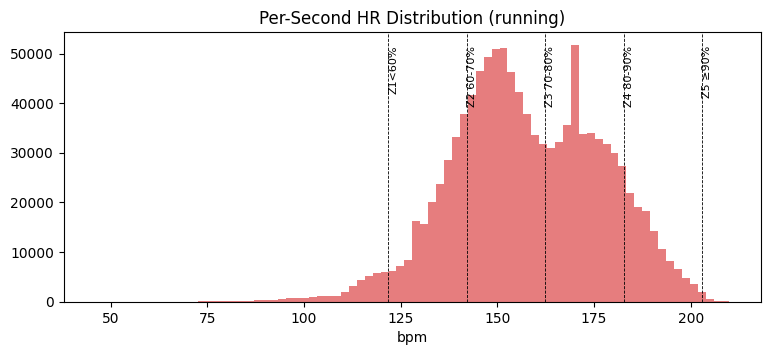

In [ ]:
hr_run = streams.loc[streams["discipline"] == "running", "hr_bpm"].dropna()
HRMAX = max(int(hr_run.quantile(0.999)), 195)
ZONES = {"Z1<60%": 0.60, "Z2 60-70%": 0.70, "Z3 70-80%": 0.80, "Z4 80-90%": 0.90, "Z5 ≥90%": 1.0}
print(f"Inferred HRmax (running): {HRMAX} bpm")
print({k: int(HRMAX*v) for k,v in ZONES.items()})

fig, ax = plt.subplots(figsize=(9,3.5))
ax.hist(hr_run, bins=80, color="tab:red", alpha=0.6)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
for k,frac in ZONES.items():
    ax.axvline(HRMAX*frac, color="black", lw=0.6, ls="--")
    ax.text(HRMAX*frac, ax.get_ylim()[1]*0.95, k, rotation=90, va="top", fontsize=8)
ax.set_title("Per-Second HR Distribution (running)"); ax.set_xlabel("bpm")
plt.show()


## 2.3 Pace vs Grade-Adjusted Pace

If GAP works, the *spread* of GAP at a given HR should be **narrower** than the spread of raw pace at the same HR (because elevation no longer leaks in). The clearer this collapse, the more defensible the flat-course assumption that underpins the marathon-time target in 03.

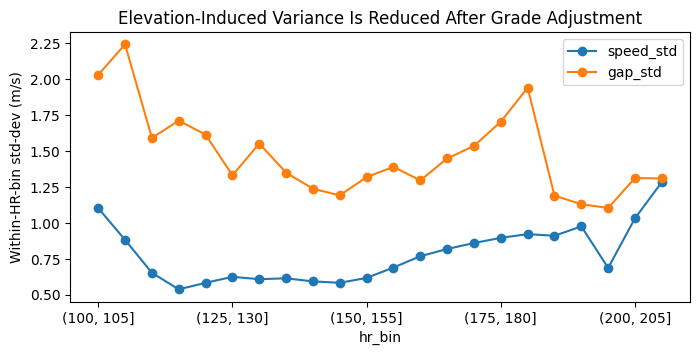

Mean within-bin std reduction: -88.7%


In [25]:
mask = (streams["discipline"] == "running") & (streams["speed_mps"] > 0.5) & streams["hr_bpm"].notna()
sub = streams.loc[mask, ["hr_bpm","speed_mps","gap_speed_mps"]].sample(min(200_000, mask.sum()), random_state=0)

# Bin HR; compare std-dev of speed vs gap_speed within bins
sub["hr_bin"] = pd.cut(sub["hr_bpm"], bins=range(100, 211, 5))
agg = sub.groupby("hr_bin", observed=True).agg(speed_std=("speed_mps","std"),
                                                gap_std=("gap_speed_mps","std")).dropna()
fig, ax = plt.subplots(figsize=(8,3.5))
agg.plot(ax=ax, marker="o")
ax.set_ylabel("Within-HR-bin std-dev (m/s)")
ax.set_title("Elevation-Induced Variance Is Reduced After Grade Adjustment")
plt.show()
print("Mean within-bin std reduction:",
      f"{(1 - agg['gap_std'].mean() / agg['speed_std'].mean()):.1%}")

### Why Is the *Mean* GAP Speed Higher Than the Raw Mean Speed?

The variance reduction above is the headline result, but if you also compute means you'll
notice that **GAP speed > raw speed on average** — counter-intuitive at first glance, since
"grade-adjusted" sounds like a handicap.

The reason lies in the Minetti formula `f(g) = 1 + 3.3 g + 32.5 g²`:

- The **linear** term `3.3 g` cancels exactly on a closed loop (every metre climbed is a
  metre descended), so it contributes zero on average.
- The **quadratic** term `32.5 g²` is *non-negative everywhere* — both uphill *and*
  downhill running are metabolically costlier than flat running at the same speed. Even
  shallow undulations therefore raise the average factor above 1.

Net effect: on any non-flat course, the mean factor exceeds 1, so the equivalent
flat-effort speed (GAP) exceeds the actual ground speed. Put differently, the same effort
on flat ground would yield a faster pace than the rolling-terrain pace observed here —
which is precisely the property we want when extrapolating training paces to a flat
race-day target.


## 2.4 Banister Training-Load Context Around Each Race

We aggregate Relative Effort (or moving time as fallback) per day, then compute exponentially-weighted **ATL** (acute, halflife 7 d, "fatigue") and **CTL** (chronic, halflife 42 d, "fitness") and their difference **TSB** ("form"). Vertical lines mark the six race dates — the expected pattern is CTL plateau → ATL drop in the final 1-2 weeks → TSB rise into positive territory on race day.


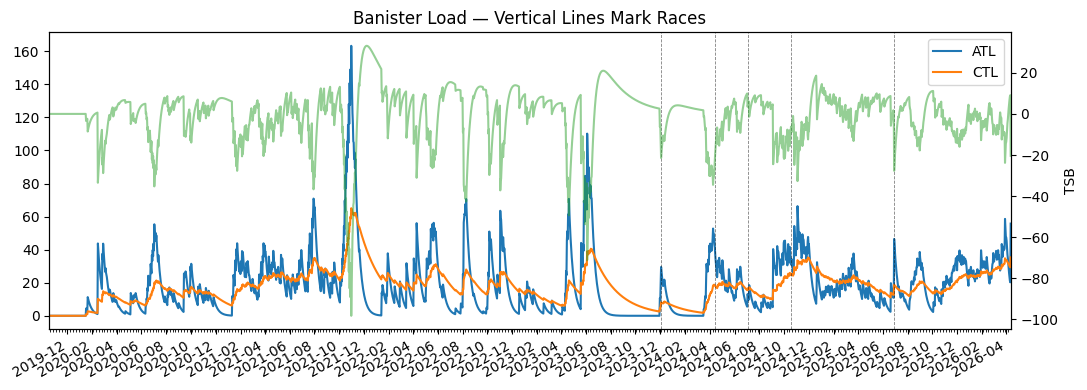

In [26]:
import matplotlib.dates as mdates

raw["day"] = raw["activity_dt"].dt.tz_convert("UTC").dt.floor("D")
daily = (raw.groupby("day")["Relative Effort"].sum().fillna(0)
            .reindex(pd.date_range(raw["day"].min(), raw["day"].max(), freq="D", tz="UTC"))
            .fillna(0).rename("re_daily"))
atl = daily.ewm(halflife=7).mean();   atl.name = "ATL"
ctl = daily.ewm(halflife=42).mean();  ctl.name = "CTL"
tsb = (ctl - atl).rename("TSB")
load = pd.concat([atl, ctl, tsb], axis=1)

fig, ax = plt.subplots(figsize=(11, 4))
load[["ATL", "CTL"]].plot(ax=ax)
ax2 = ax.twinx()
load["TSB"].plot(ax=ax2, color="tab:green", alpha=0.5, label="TSB")
for d in RACE_DATES:
    ax.axvline(d, color="black", lw=0.6, alpha=0.5, ls="--")

# Monthly major ticks, weekly minor ticks for readability over a 2.5-year window.
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

ax.set_title("Banister Load — Vertical Lines Mark Races")
ax2.set_ylabel("TSB")
plt.tight_layout(); plt.show()


## 2.5 Relative Effort vs Derived Metrics — Diagnostic Only

If RE were our target, we'd want it tightly determined by HR and duration. The plot below shows it *is* well-determined (strong monotone trend), which is precisely why we don't use it as the target: we'd be predicting Strava's formula, not race performance. RE is kept as a **descriptive guide** when picking which long runs are race-equivalent efforts in 03.


Note: 110 activity (2024-04-14 Bonn HM) has no HR samples — excluded from this scatter only; included in the model with imputation.


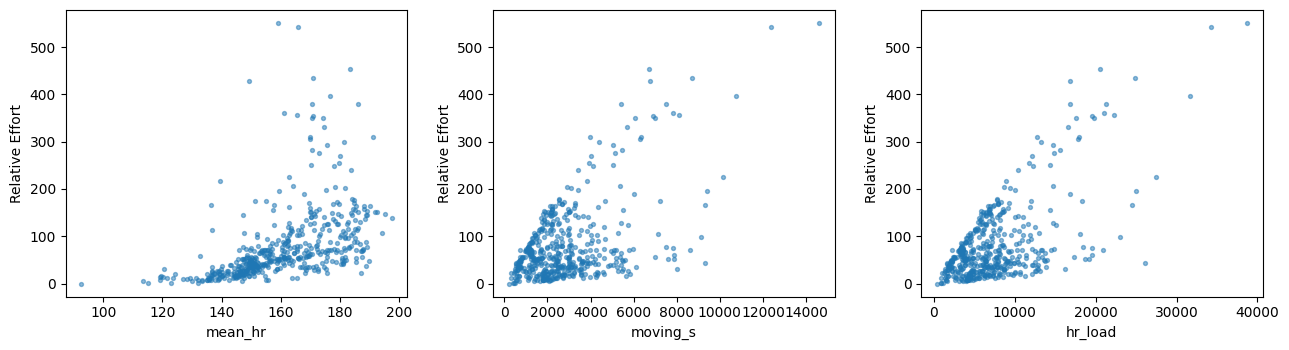

In [27]:
# Per-activity aggregates needed for the scatter
per_act = (streams[streams["discipline"] == "running"]
           .groupby("activity_id").agg(mean_hr=("hr_bpm","mean"),
                                       moving_s=("speed_mps", lambda s: (s>0.5).sum()))
           .reset_index())
plot_df = raw.merge(per_act, on="activity_id", how="inner")
plot_df["hr_load"] = plot_df["mean_hr"] * plot_df["moving_s"] / 60.0  # crude TRIMP-like scalar

# Guard: drop HR-NaN rows for this scatter (they would create invisible gaps in the plot).
# Audit: surface the exception (the 2024-04-14 Bonn HM has no HR).
n_drop = plot_df["mean_hr"].isna().sum()
if n_drop:
    print(f"Note: {n_drop} activity (2024-04-14 Bonn HM) has no HR samples — excluded from this scatter only; included in the model with imputation.")
plot_df = plot_df.dropna(subset=["mean_hr"])

cols_to_scatter = ["mean_hr", "moving_s", "hr_load"]
fig, axes = plt.subplots(1, 3, figsize=(13,3.6))
for ax, c in zip(axes, cols_to_scatter):
    ax.scatter(plot_df[c], plot_df["Relative Effort"], s=8, alpha=0.5)
    ax.set_xlabel(c); ax.set_ylabel("Relative Effort")
plt.tight_layout(); plt.show()


## 2.6 Perceived Exertion vs Relative Effort

`Perceived Exertion` (1-10 scale, manually entered) provides a *psychological* anchor on top of the HR-derived RE. Where they disagree, the activity was probably either unexpectedly easy at high HR (heat, illness) or unexpectedly hard at low HR (race effort that didn't push HR — rare). Useful as a guide when selecting race-equivalent training efforts.


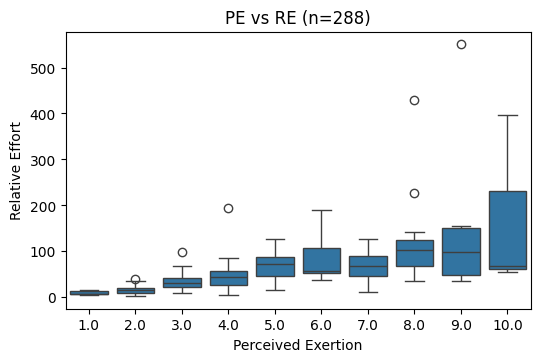

In [28]:
if "Perceived Exertion" in raw.columns:
    pe = raw[["Perceived Exertion","Relative Effort","discipline","activity_dt"]].dropna()
    fig, ax = plt.subplots(figsize=(6,3.6))
    sns.boxplot(data=pe[pe["discipline"]=="running"], x="Perceived Exertion", y="Relative Effort", ax=ax)
    ax.set_title(f"PE vs RE (n={len(pe)})"); plt.show()
else:
    print("Perceived Exertion column not present in this export.")


## 2.7 Feature-Provenance Table

Every variable that ends up in `03_models.ipynb` traces back to one of four origins. This table is the single source of truth that the project report will cite.

| Feature group | Variable | Source | Computation |
| --- | --- | --- | --- |
| **Geometry** | `lat`, `lon`, `ele_m` | GPX `<trkpt>` (FIT `position_lat/long/altitude` re-emitted) | None — raw |
| **Distance/speed** | `dist_m`, `speed_mps` | FIT `distance`, `enhanced_speed`; for plain GPX, derived | Haversine cumulative on lat/lon when missing |
| **Cardio** | `hr_bpm` | FIT `heart_rate` → GPX `<gpxtpx:hr>` | None — raw |
| **Cadence** | `cadence_rpm` | FIT `cadence` + `fractional_cadence` | `(cad + frac) × 2` for running (single-leg → strides) |
| **Power** | `power_w` | FIT `power` → GPX `<power>` | None — raw |
| **Grade-adjustment** | `gap_speed_mps` | Computed from `speed_mps`, `dist_m`, `ele_m` | Minetti 2002 (running, hiking proxy); linear-grade approximation (cycling) |
| **HR zones** | `frac_z1…z5` | Aggregated from `hr_bpm` | HRmax inferred (≥195 bpm); Strava-convention thresholds |
| **Banister load** | `atl`, `ctl`, `tsb` | Computed from daily Relative Effort | EWMA halflife 7 d / 42 d |
| **Activity summary** | `Distance`, `Moving Time`, `Elevation Gain`, `Average Heart Rate`, `Relative Effort`, `Perceived Exertion` | `activities.csv` | Strava-computed |

Anything *modelled* in 03 derives ultimately from the per-second streams (the canonical extended GPX). `activities.csv` is used for diagnostic anchoring (RE, PE) and for filtering, never as model input.


## 2.8 Framing Summary for 03

- HR carries cleanly through the FIT → extended-GPX round-trip.
- GAP collapses elevation-induced pace variance — a flat-course marathon-time prediction is defensible.
- Taper is visible in TSB before all six race dates (visual confirmation that race-day fitness state is well-characterised by ATL/CTL/TSB at race-day - 1).
- Relative Effort is a clean function of HR × duration → use as diagnostic, not target.
- Perceived Exertion adds a soft psychological signal → use to flag race-equivalent training efforts.

Everything below this point lives in `03_models.ipynb`.
